# 🤖 Classification Practice Project

### 📊 Dataset

In [1]:
import pandas as pd
import numpy as np

customers = {
    "Age": [
        22, 25, 29, 31, 35,
        40, 28, 45, 50, 24,
        33, 38, 27, 42, 36,
        48, 30, 26, 52, 41
    ],

    "Monthly_Charges": [
        30, 35, 50, 70, 85,
        90, 45, 100, 110, 32,
        65, 80, 40, 95, 75,
        105, 55, 38, 120, 88
    ],

    "Tenure_Months": [
        2, 4, 8, 12, 18,
        24, 6, 30, 36, 3,
        15, 20, 5, 28, 22,
        40, 10, 7, 48, 26
    ],

    "Support_Calls": [
        5, 4, 3, 2, 1,
        1, 4, 1, 0, 5,
        2, 1, 5, 1, 2,
        0, 3, 4, 0, 1
    ],

    "Satisfaction": [
        2, 2, 3, 4, 5,
        5, 2, 5, 5, 1,
        4, 4, 2, 5, 4,
        5, 3, 2, 5, 4
    ],

    "Churn": [
        1, 1, 1, 0, 0,
        0, 1, 0, 0, 1,
        0, 0, 1, 0, 0,
        0, 1, 1, 0, 0
    ]
}

df = pd.DataFrame(customers)

print(df)

    Age  Monthly_Charges  Tenure_Months  Support_Calls  Satisfaction  Churn
0    22               30              2              5             2      1
1    25               35              4              4             2      1
2    29               50              8              3             3      1
3    31               70             12              2             4      0
4    35               85             18              1             5      0
5    40               90             24              1             5      0
6    28               45              6              4             2      1
7    45              100             30              1             5      0
8    50              110             36              0             5      0
9    24               32              3              5             1      1
10   33               65             15              2             4      0
11   38               80             20              1             4      0
12   27     

### Task 1 — Inspect the Dataset

In [2]:
print(df.head())
print(df.tail())
print(df.shape)
print(df.dtypes)

   Age  Monthly_Charges  Tenure_Months  Support_Calls  Satisfaction  Churn
0   22               30              2              5             2      1
1   25               35              4              4             2      1
2   29               50              8              3             3      1
3   31               70             12              2             4      0
4   35               85             18              1             5      0
    Age  Monthly_Charges  Tenure_Months  Support_Calls  Satisfaction  Churn
15   48              105             40              0             5      0
16   30               55             10              3             3      1
17   26               38              7              4             2      1
18   52              120             48              0             5      0
19   41               88             26              1             4      0
(20, 6)
Age                int64
Monthly_Charges    int64
Tenure_Months      int64
Support_Cal

### Task 2 — EDA

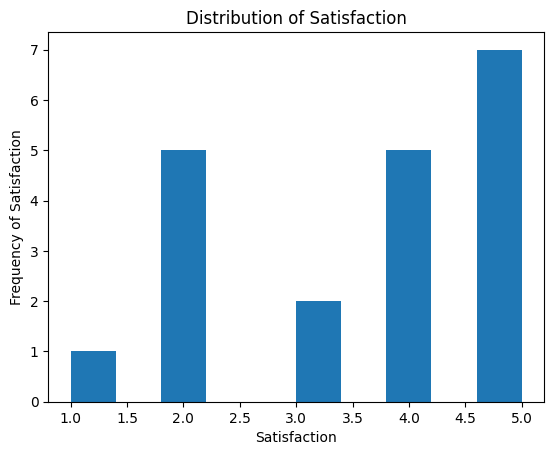

In [4]:
import matplotlib.pyplot as plt

plt.hist(df["Satisfaction"])

plt.xlabel("Satisfaction")
plt.ylabel("Frequency of Satisfaction")
plt.title("Distribution of Satisfaction")

plt.show()

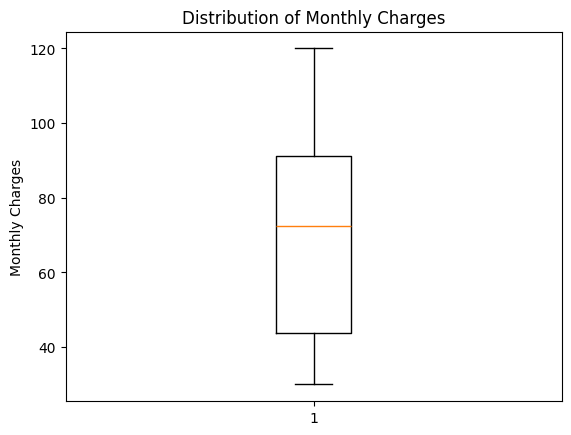

In [5]:
plt.boxplot(df["Monthly_Charges"])

plt.ylabel("Monthly Charges")
plt.title("Distribution of Monthly Charges")

plt.show()

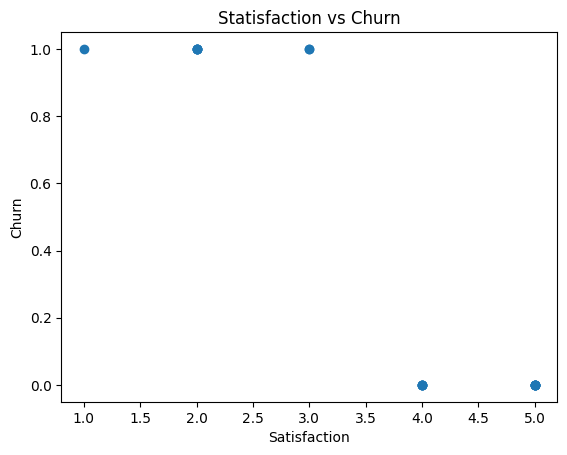

In [6]:
plt.scatter(df["Satisfaction"], df["Churn"])

plt.xlabel("Satisfaction")
plt.ylabel("Churn")
plt.title("Statisfaction vs Churn")

plt.show()

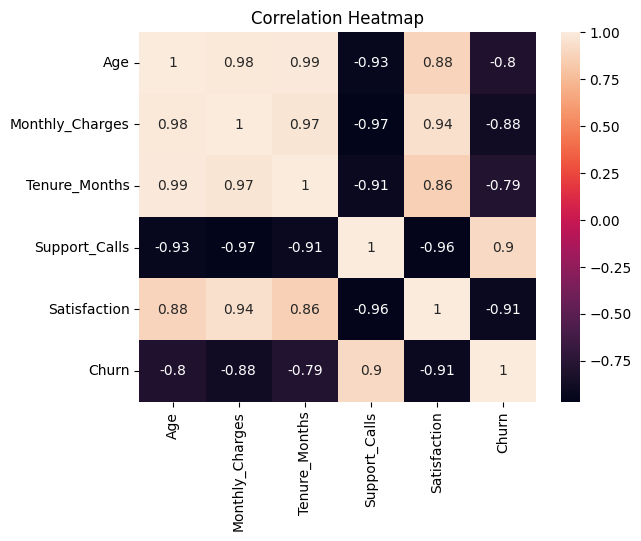

In [8]:
import seaborn as sns

correlation = df.corr(numeric_only=True)

sns.heatmap(correlation, annot=True)

plt.title("Correlation Heatmap")
plt.show()

### Task 3 — Class Distribution

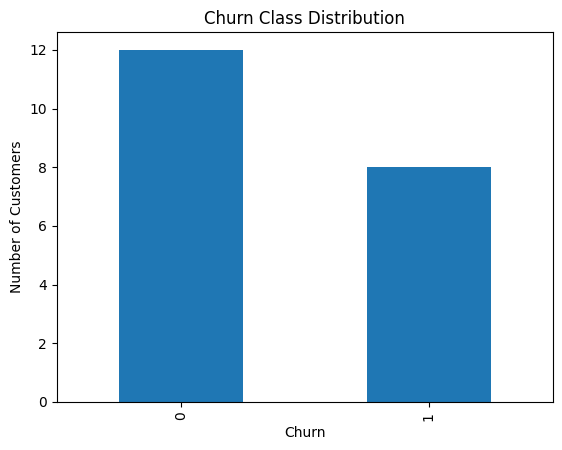

In [13]:
df["Churn"].value_counts().plot(kind="bar")

plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.title("Churn Class Distribution")
plt.show()

### Task 4 — Define X and y

In [14]:
X = df[[
    "Age", 
    "Monthly_Charges", 
    "Tenure_Months", 
    "Support_Calls", 
    "Satisfaction"
]]

y = df["Churn"]

### Task 5 — Train/Test Split

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Task 6 — Feature Scaling

In [16]:
from sklearn.preprocessing import StandardScaler

scale = StandardScaler()

train_scale = scale.fit_transform(X_train)
test_scale = scale.transform(X_test)

### Task 7 — Logistic Regression

In [17]:
from sklearn.linear_model import LogisticRegression

logic_model = LogisticRegression()

logic_model.fit(train_scale, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Task 8 — Predictions

In [18]:
prediction = logic_model.predict(test_scale)
probabilites = logic_model.predict_proba(test_scale)

print("Predicted classes: ", prediction)
print("Predicted probabilities: ", probabilites)

Predicted classes:  [1 1 0 1]
Predicted probabilities:  [[0.02135167 0.97864833]
 [0.06673042 0.93326958]
 [0.99763728 0.00236272]
 [0.0511682  0.9488318 ]]


### Task 9 — Evaluation

In [19]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score

accuracy = accuracy_score(y_test, prediction)
precision = precision_score(y_test, prediction)
f1 = f1_score(y_test, prediction)
recall  = recall_score(y_test, prediction)

In [20]:
from sklearn.metrics import confusion_matrix

c_matrix = confusion_matrix(y_test, prediction)

print(c_matrix)

tn, fp, fn, tp = c_matrix.ravel()
print(tn)
print(fp)
print(fn)
print(tp)

[[1 0]
 [0 3]]
1
0
0
3


### Task 11 🔥 — Result Table

In [28]:
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": prediction,
    "Churn_Probability": probabilites[:, 1]
})

print(result)

   Actual  Predicted  Churn_Probability
0       1          1           0.978648
1       1          1           0.933270
2       0          0           0.002363
3       1          1           0.948832


### Task 12 🔥 — New Customer

In [27]:
new_customer = pd.DataFrame({
    "Age": [32],
    "Monthly_Charges": [85],
    "Tenure_Months": [10],
    "Support_Calls": [4],
    "Satisfaction": [2]
})

new_customer_scaled = scale.transform(new_customer)

new_pred = logic_model.predict(new_customer_scaled)
new_prob = logic_model.predict_proba(new_customer_scaled)

print("Predicted class: ", new_pred)
print("Probability of churn ", new_prob)

Predicted class:  [1]
Probability of churn  [[0.30594094 0.69405906]]


### Task 13 — Final Model Summary

In [25]:
results_summary = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1
}

print(results_summary)

{'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0}
